In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns
import numpy as np

In [2]:
#load the data into dataframe
df = pd.read_csv('train.csv')

In [3]:
#display the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


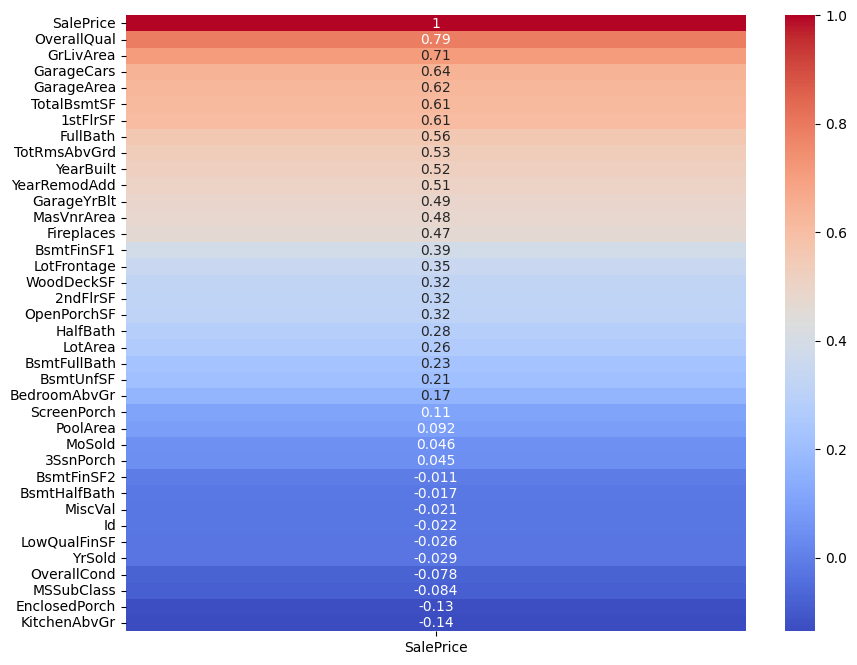

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice', ascending=False),
            annot=True, cmap='coolwarm')
plt.show()

In [22]:
# Select relevant feature and target
features = [
    'GrLivArea',
    'OverallQual',
    'YearBuilt',
    'TotalBsmtSF',
    'GarageCars',
    'GarageArea',
    'FullBath',
    'TotRmsAbvGrd'
]

df = df[features + ['SalePrice']].copy()

In [6]:
# Check for missing values in the selected columns
print(df.isnull().sum())

GrLivArea       0
OverallQual     0
YearBuilt       0
TotalBsmtSF     0
GarageCars      0
GarageArea      0
FullBath        0
TotRmsAbvGrd    0
SalePrice       0
dtype: int64


# Train/Test Split

We split the data into training and test set;test data is held out to evaluate performance on new examples

Overfitting means the model learns noise/specifics rather than the true pattern,leading to poor predictions on new data.

In [21]:
# Seperate features(x) and target (y)
x = df[features] #input features
y= df['SalePrice'] #target variable

In [8]:
# Split into training and test sets(80% train, 20% test)
# random_state ensures reproducability
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

This will help us see if the model is able to generalize(perform well on unseen houses)

# Model Building

## In linear regression, we fit a line that best predicts the target from the features

## Mathematically: SalePrice(Y) = intercept + coeff1*GrLivArea + coeff2*OverallQual + coeff3*YearBuilt

In [9]:
# Initialize the linear regression model
model = LinearRegression()

In [10]:
# Fit the model on training data
model.fit(x_train, y_train)

LinearRegression()

The model learns the best fitting line through the training data

It computes the coefficients and intercept(weights) that minimize prediction errors on the training set.

# Predictions

A prediction is
the model's estimated sale price for a house it hasn't seen before

In [20]:
# Predict sale prices forthe test set
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([146734.77658671, 305179.75443819, 101276.51679216, 174336.9276859 ,
       276139.58252692,  75989.6330014 , 212177.10473475, 177788.17415777,
        74960.03301119, 137639.26753201, 177831.11747824, 113122.91649551,
        48296.84353112, 220443.60025935, 203184.77159858, 113458.6673018 ,
       231568.10686818, 124638.95825518, 121230.95858042, 216561.38204751,
       163323.17946612, 250330.24723285, 192890.42338875, 110673.5295799 ,
       211615.82359561, 170056.12976831, 210262.16895427,  79249.83065264,
       196468.97935185, 210468.95857704, 104964.98975205, 250656.49149188,
       234810.33616391,  87115.48782589, 252066.7407778 , 151853.38441152,
       165792.95878412, 243560.86024949, 298531.44269119, 107426.37629948,
       138299.88328947, 249871.7694979 , 119237.38406067, 277510.12283929,
       116374.41789953, 172677.65562688, 113348.750305  , 116964.04642592,
       341824.09223988, 147061.02084575, 110711.61795336, 183948.07812797,
       143098.27776337, 3

model.predict(x_test) gives an array of predicted prices(one for each house in x_test)

These predictions come from the linear formula with the learned coefficients

# Model Evaluation

Compare the predicted prices(y_pred) to the actual prices (y_test) to see how well our model is doing.

Metrics:
  1. Error(Residual) = y_pred - y_test
  2. Mean Squared Error(MSE) : This is the average of the squares of these errors. It measures average squared error in price dollars
  3. Root Mean Squared Errors(RMSE): The square root of MSE: It tells us roughly how far our predictions are on average


In [19]:
# Calculate the MSE and RMSE on the test set
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"New RMSE: {rmse:.2f}")

New RMSE: 39661.96


RMSE reveals that our a model is  off by about $39661 dollars

# Interpretation

## The model gave us a coefficient(slope) for each feature and interept. We interpret them as:
   ## 1. Intercept: The predicted price when all features are zero. It is baseline price.
   ## 2. Feature coefficients: How much the predicted price changes when that feature increases by one unit(holding other features constant)

  

In [23]:
# Show the learned coefficients and intercept
coeffs = pd.Series(model.coef_, index=features)
print("Intercept:", model.intercept_)
print("Coefficients:\n", coeffs)

Intercept: -760213.5007789708
Coefficients:
 GrLivArea          50.665761
OverallQual     20571.617037
YearBuilt         350.632989
TotalBsmtSF        23.765506
GarageCars      11780.740374
GarageArea         14.984857
FullBath        -5133.323660
TotRmsAbvGrd      302.878008
dtype: float64


##According to our model OverallQual is the most influential feature since one unit in overall quality bumps up the price by $ 24520